# Chapter 10: Handling Missing Data: Detection, Removal, Imputation, and Best Practices

**Companion notebook** for *Beginner's Guide to Pandas* by Ravi Shankar

Run each cell in order. Exercises are at the end.

In [61]:
import pandas as pd
import numpy as np

# Handling Missing Data: Detection, Removal, Imputation, and Best Practices

Missing data is one of the most common challenges in real-world data analysis. Whether it comes from sensor failures, incomplete surveys, measurement errors, or data entry problems, knowing how to identify and handle missing values is essential for producing reliable results. This chapter covers practical strategies for detecting, removing, imputing, and working with missing data in pandas — including how to handle duplicate records that often appear alongside data quality issues.

---

## Why Missing Data Matters

Before diving into techniques, it helps to understand what's at stake:

- **Missing values affect calculations** — `.mean()` ignores `NaN` by default, but if you're unaware of the extent of missingness, you might think you're analyzing the full dataset when you're not.
- **Unhandled missing data leads to incorrect conclusions** and unreliable models.
- **Understanding *why* data is missing** (random vs. systematic) helps you choose the right strategy.

Pandas recognizes several representations of missing data across different data types:

- **`NaN` (Not a Number)**: The default marker for missing numeric data
- **`None`**: Python's null object, often used in object-type columns
- **`NaT` (Not a Time)**: The missing value indicator for datetime objects

### How Pandas Stores Missing Values

Different data types require different missing value representations for computational efficiency:

In [62]:
import pandas as pd
import numpy as np

# Numeric data uses NaN
numeric_series = pd.Series([1.5, 2.3, None, 4.1])
print("Numeric series:")
print(numeric_series)
# None is converted to NaN for float columns

# Datetime data uses NaT
date_series = pd.Series([pd.Timestamp('2023-01-01'), None, pd.Timestamp('2023-01-03')])
print("\nDatetime series:")
print(date_series)
# None is converted to NaT for datetime columns

# Object data preserves None
object_series = pd.Series(['apple', None, 'banana'])
print("\nObject series:")
print(object_series)
# None is preserved as-is in object columns

Numeric series:
0    1.5
1    2.3
2    NaN
3    4.1
dtype: float64

Datetime series:
0   2023-01-01
1          NaT
2   2023-01-03
dtype: datetime64[ns]

Object series:
0     apple
1      None
2    banana
dtype: object


**Key insight:** When you introduce `NaN` into an integer column, pandas converts it to `float64` because integers cannot represent missing values natively.

In [63]:
# Demonstrate integer-to-float conversion
df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],    # NaN forces float64
    'B': [5, None, 7, 8],       # None in object column
    'C': [9, 10, 11, 12]        # No missing values, stays int64
})

print(df)
print("\nData types:")
print(df.dtypes)

     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  7.0  11
3  4.0  8.0  12

Data types:
A    float64
B    float64
C      int64
dtype: object


Output:
```
     A     B   C
0  1.0     5   9
1  2.0  None  10
2  NaN     7  11
3  4.0     8  12

Data types:
A    float64
B     object
C      int64
```

---

## Detecting Missing Data

### Using `isna()` and `isnull()`

The most reliable way to identify missing values is through pandas' detection functions. `isna()` and `isnull()` are equivalent; `isna()` is the modern, recommended approach:

In [64]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

# isna() returns a boolean DataFrame — True where values are missing
print("Using isna():")
print(df.isna())

# notna() returns the inverse — True where values are present
print("\nUsing notna():")
print(df.notna())

Using isna():
       A      B      C
0  False  False  False
1  False   True  False
2   True   True  False
3  False  False  False

Using notna():
       A      B     C
0   True   True  True
1   True  False  True
2  False  False  True
3   True   True  True


Output:
```
Using isna():
       A      B      C
0  False  False  False
1  False   True  False
2   True   True  False
3  False  False  False

Using notna():
       A      B      C
0   True   True   True
1   True  False   True
2  False  False   True
3   True   True   True
```

### Getting a Missing Data Summary

Understanding the extent of missing data helps inform your strategy:

In [65]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8],
    'humidity':    [65,   70,    np.nan, 72],
    'location':    ['Room A', None, 'Room B', 'Room C'],
    'timestamp':   [pd.Timestamp('2023-01-01'), pd.Timestamp('2023-01-02'),
                    pd.NaT, pd.Timestamp('2023-01-04')]
})

# Count missing values per column
print("Missing counts:")
print(df.isna().sum())

# Percentage of missing data
print("\nMissing percentages:")
print((df.isna().sum() / len(df)) * 100)

# Total missing values across the entire DataFrame
print("\nTotal missing values:", df.isna().sum().sum())

# Find rows with ANY missing values
print("\nRows with any missing values:")
print(df[df.isna().any(axis=1)])

# Find rows with ALL values present
print("\nComplete rows:")
print(df[df.notna().all(axis=1)])

Missing counts:
temperature    1
humidity       1
location       1
timestamp      1
dtype: int64

Missing percentages:
temperature    25.0
humidity       25.0
location       25.0
timestamp      25.0
dtype: float64

Total missing values: 4

Rows with any missing values:
   temperature  humidity location  timestamp
1          NaN      70.0     None 2023-01-02
2         21.3       NaN   Room B        NaT

Complete rows:
   temperature  humidity location  timestamp
0         22.5      65.0   Room A 2023-01-01
3         20.8      72.0   Room C 2023-01-04


Output:
```
Missing counts:
temperature    1
humidity       1
location       1
timestamp      1
dtype: int64

Missing percentages:
temperature    25.0
humidity       25.0
location       25.0
timestamp      25.0
dtype: float64

Total missing values: 4
```

### Using `.info()` for a Quick Overview

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   temperature  3 non-null      float64       
 1   humidity     3 non-null      float64       
 2   location     3 non-null      object        
 3   timestamp    3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 256.0+ bytes


Output:
```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   temperature  3 non-null      float64
 1   humidity     3 non-null      float64
 2   location     3 non-null      object
 3   timestamp    3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
```

`.info()` instantly shows which columns have missing data and how many non-null values remain — a useful first step in any data quality check.

### Visualizing Missing Data Patterns

For larger datasets, a visual overview of missingness can reveal patterns that summary statistics miss:

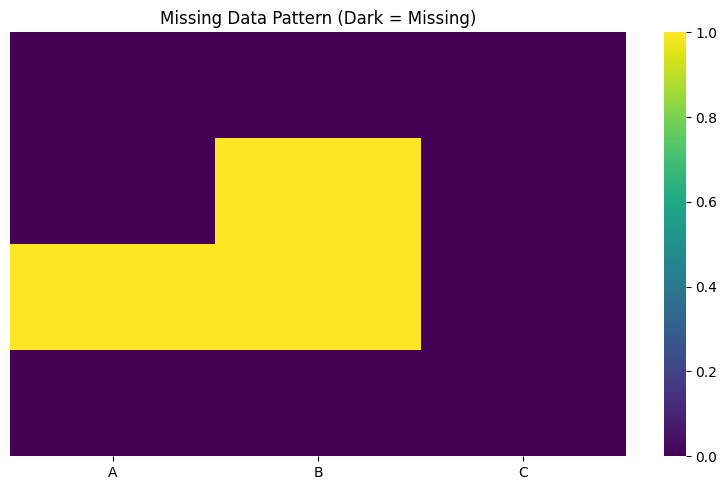

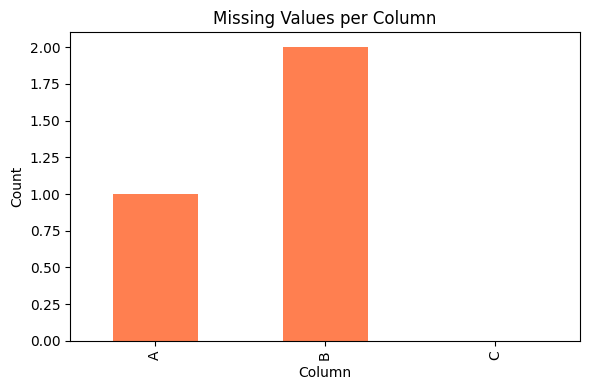

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

# Heatmap of missing data
plt.figure(figsize=(8, 5))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Missing Data Pattern (Dark = Missing)")
plt.tight_layout()
plt.show()

# Bar chart of missing counts
plt.figure(figsize=(6, 4))
df.isna().sum().plot(kind='bar', color='coral')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

---

## Removing Missing Data

### The `dropna()` Method

Removing rows or columns with missing values is the simplest approach. Use it carefully — dropping too aggressively can introduce bias.

In [68]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

print("Original DataFrame:")
print(df)
print(f"Shape: {df.shape}\n")

# Drop rows with ANY missing values (default)
print("After dropna():")
print(df.dropna())

# Drop rows where ALL values are missing
print("\nDrop rows where ALL values are missing:")
print(df.dropna(how='all'))

# Drop rows missing values in specific columns
print("\nDrop rows missing values in column A:")
print(df.dropna(subset=['A']))

# Keep rows with at least 2 non-null values
print("\nKeep rows with at least 2 non-null values (thresh=2):")
print(df.dropna(thresh=2))

# Drop columns with any missing values
print("\nDrop columns with any missing values:")
print(df.dropna(axis=1))

Original DataFrame:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12
Shape: (4, 3)

After dropna():
     A    B   C
0  1.0  5.0   9
3  4.0  8.0  12

Drop rows where ALL values are missing:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12

Drop rows missing values in column A:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
3  4.0  8.0  12

Keep rows with at least 2 non-null values (thresh=2):
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
3  4.0  8.0  12

Drop columns with any missing values:
    C
0   9
1  10
2  11
3  12


By default, `dropna()` returns a new DataFrame. Use `inplace=True` to modify in place:

In [69]:
df.dropna(inplace=True)  # Modifies df directly

### When to Remove vs. Impute

**Remove missing data when:**
- Missing values represent less than 5% of your dataset
- Missing values are completely random (MCAR — Missing Completely At Random)
- The missing column is not critical to your analysis
- You have sufficient data remaining after removal

**Avoid removing when:**
- Missing data is substantial (more than 10–20% of a column)
- Missing data follows a pattern (MNAR — Missing Not At Random)
- The column is important for your analysis
- Removal would create bias in your results

---

## Imputation Strategies

Imputation fills missing values with estimated data. The right strategy depends on your data type, the pattern of missingness, and your analysis goals.

### Strategy 1: Fill with Constant Values

Best when missing values have a logical default — for example, 0 for counts or "Unknown" for categories:

In [70]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8],
    'humidity':    [65,   70,    np.nan, 72],
    'location':    ['Room A', None, 'Room B', 'Room C']
})

# Fill all missing values with a single constant
df_filled = df.fillna(0)
print("Filled with 0:")
print(df_filled)

# Fill different columns with different values
fill_values = {
    'temperature': 0,
    'humidity': 50,
    'location': 'Unknown'
}
df_custom = df.fillna(fill_values)
print("\nFilled with custom values per column:")
print(df_custom)

Filled with 0:
   temperature  humidity location
0         22.5      65.0   Room A
1          0.0      70.0        0
2         21.3       0.0   Room B
3         20.8      72.0   Room C

Filled with custom values per column:
   temperature  humidity location
0         22.5      65.0   Room A
1          0.0      70.0  Unknown
2         21.3      50.0   Room B
3         20.8      72.0   Room C


### Strategy 2: Fill with Statistical Values

Best when missing values should reflect the central tendency of the data:

In [71]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8],
    'humidity':    [65,   70,    np.nan, 72],
    'location':    ['Room A', None, 'Room B', 'Room A']
})

# Mean imputation (sensitive to outliers)
df_mean = df.copy()
df_mean['temperature'] = df_mean['temperature'].fillna(df_mean['temperature'].mean())
print("Mean imputation:")
print(df_mean)

# Median imputation (more robust to outliers)
df_median = df.copy()
df_median['humidity'] = df_median['humidity'].fillna(df_median['humidity'].median())
print("\nMedian imputation:")
print(df_median)

# Mode imputation (for categorical data)
df_mode = df.copy()
df_mode['location'] = df_mode['location'].fillna(df_mode['location'].mode()[0])
print("\nMode imputation:")
print(df_mode)

Mean imputation:
   temperature  humidity location
0    22.500000      65.0   Room A
1    21.533333      70.0     None
2    21.300000       NaN   Room B
3    20.800000      72.0   Room A

Median imputation:
   temperature  humidity location
0         22.5      65.0   Room A
1          NaN      70.0     None
2         21.3      70.0   Room B
3         20.8      72.0   Room A

Mode imputation:
   temperature  humidity location
0         22.5      65.0   Room A
1          NaN      70.0   Room A
2         21.3       NaN   Room B
3         20.8      72.0   Room A


### Strategy 3: Forward Fill and Backward Fill

Best for time-series data where values change gradually and the previous or next observation is a reasonable estimate:

In [72]:
import pandas as pd
import numpy as np

ts_df = pd.DataFrame({
    'date':        pd.date_range('2024-01-01', periods=5),
    'temperature': [20, np.nan, 22, np.nan, 25],
    'humidity':    [60, 65, np.nan, 75, 80]
})

print("Original:")
print(ts_df)

# Forward-fill: use the previous valid value
print("\nForward-filled:")
print(ts_df.ffill())

# Backward-fill: use the next valid value
print("\nBackward-filled:")
print(ts_df.bfill())

# Limit fill to prevent over-propagation
print("\nForward-filled (limit=1):")
print(ts_df.ffill(limit=1))

Original:
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02          NaN      65.0
2 2024-01-03         22.0       NaN
3 2024-01-04          NaN      75.0
4 2024-01-05         25.0      80.0

Forward-filled:
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02         20.0      65.0
2 2024-01-03         22.0      65.0
3 2024-01-04         22.0      75.0
4 2024-01-05         25.0      80.0

Backward-filled:
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02         22.0      65.0
2 2024-01-03         22.0      75.0
3 2024-01-04         25.0      75.0
4 2024-01-05         25.0      80.0

Forward-filled (limit=1):
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02         20.0      65.0
2 2024-01-03         22.0      65.0
3 2024-01-04         22.0      75.0
4 2024-01-05         25.0      80.0


### Strategy 4: Group-Based Filling

Best when missing values should be filled based on group membership — for example, filling with the regional average rather than the overall average:

In [73]:
import pandas as pd
import numpy as np

sales = pd.DataFrame({
    'region': ['North', 'North', 'North', 'South', 'South', 'South'],
    'amount': [100, np.nan, 150, 200, np.nan, 250]
})

print("Original:")
print(sales)

# Fill missing amounts with the mean for each region
sales['amount'] = sales.groupby('region')['amount'].transform(
    lambda x: x.fillna(x.mean())
)

print("\nAfter group-based fill:")
print(sales)

Original:
  region  amount
0  North   100.0
1  North     NaN
2  North   150.0
3  South   200.0
4  South     NaN
5  South   250.0

After group-based fill:
  region  amount
0  North   100.0
1  North   125.0
2  North   150.0
3  South   200.0
4  South   225.0
5  South   250.0


Output:
```
Original:
  region  amount
0  North   100.0
1  North     NaN
2  North   150.0
3  South   200.0
4  South     NaN
5  South   250.0

After group-based fill:
  region  amount
0  North   100.0
1  North   125.0
2  North   150.0
3  South   200.0
4  South   225.0
5  South   250.0
```

### Strategy 5: Interpolation for Sequential Data

Best when missing values fall in a numeric sequence and should follow a pattern. Linear interpolation estimates values by drawing a straight line between known points:

In [74]:
import pandas as pd
import numpy as np

# Sample data
ts_df = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=5),
    'temperature': [20.0, np.nan, 22.0, np.nan, 25.0],
    'humidity': [60.0, np.nan, 70.0, np.nan, 80.0]
})

print("Original DataFrame:")
print(ts_df)

# ----------------------------
# Linear interpolation
# ----------------------------
print("\nLinear interpolation:")
linear_df = ts_df.copy()

# Interpolate only numeric columns
numeric_cols = linear_df.select_dtypes(include=np.number).columns
linear_df[numeric_cols] = linear_df[numeric_cols].interpolate(method='linear')

print(linear_df)

# ----------------------------
# Polynomial interpolation
# ----------------------------
print("\nPolynomial interpolation (order=2):")

poly_df = ts_df.copy()

# Polynomial interpolation only on numeric columns
numeric_cols = poly_df.select_dtypes(include=np.number).columns
poly_df[numeric_cols] = poly_df[numeric_cols].interpolate(
    method='polynomial',
    order=2
)

print(poly_df)

# ----------------------------
# Limited interpolation
# ----------------------------
print("\nLimited interpolation (limit=1):")

limited_df = ts_df.copy()

numeric_cols = limited_df.select_dtypes(include=np.number).columns
limited_df[numeric_cols] = limited_df[numeric_cols].interpolate(
    method='linear',
    limit=1
)

print(limited_df)

Original DataFrame:
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02          NaN       NaN
2 2024-01-03         22.0      70.0
3 2024-01-04          NaN       NaN
4 2024-01-05         25.0      80.0

Linear interpolation:
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02         21.0      65.0
2 2024-01-03         22.0      70.0
3 2024-01-04         23.5      75.0
4 2024-01-05         25.0      80.0

Polynomial interpolation (order=2):
        date  temperature  humidity
0 2024-01-01       20.000      60.0
1 2024-01-02       20.875      65.0
2 2024-01-03       22.000      70.0
3 2024-01-04       23.375      75.0
4 2024-01-05       25.000      80.0

Limited interpolation (limit=1):
        date  temperature  humidity
0 2024-01-01         20.0      60.0
1 2024-01-02         21.0      65.0
2 2024-01-03         22.0      70.0
3 2024-01-04         23.5      75.0
4 2024-01-05         25.0      80.0


You can visualize the difference between interpolation methods:

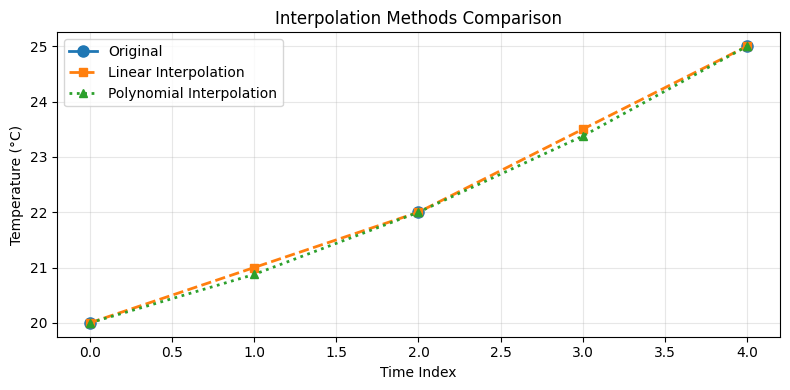

In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ts_df = pd.DataFrame({
    'temperature': [20.0, np.nan, 22.0, np.nan, 25.0]
})

ts_linear = ts_df.interpolate(method='linear')
ts_poly   = ts_df.interpolate(method='polynomial', order=2)

plt.figure(figsize=(8, 4))
plt.plot(ts_df.index, ts_df['temperature'],
         'o-', label='Original', linewidth=2, markersize=8)
plt.plot(ts_df.index, ts_linear['temperature'],
         's--', label='Linear Interpolation', linewidth=2)
plt.plot(ts_df.index, ts_poly['temperature'],
         '^:', label='Polynomial Interpolation', linewidth=2)
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.title('Interpolation Methods Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Strategy 6: Advanced Imputation with scikit-learn

For datasets where missing values depend on other features, scikit-learn provides more sophisticated imputers:

In [76]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8, 23.1],
    'humidity':    [65,   70,    np.nan, 72,   68],
    'pressure':    [1013, 1010,  1012,  np.nan, 1015]
})

# KNN imputation: fill based on k most similar rows
imputer = KNNImputer(n_neighbors=3)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("After KNN imputation:")
print(df)

After KNN imputation:
   temperature  humidity     pressure
0    22.500000      65.0  1013.000000
1    21.733333      70.0  1010.000000
2    21.300000      69.0  1012.000000
3    20.800000      72.0  1012.333333
4    23.100000      68.0  1015.000000


In [77]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8, 23.1],
    'humidity':    [65,   70,    np.nan, 72,   68],
    'pressure':    [1013, 1010,  1012,  np.nan, 1015]
})

# Iterative imputation: model each feature as a function of others
imputer = IterativeImputer(max_iter=10, random_state=42)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("After iterative imputation:")
print(df)

After iterative imputation:
   temperature   humidity     pressure
0    22.500000  65.000000  1013.000000
1    19.934598  70.000000  1010.000000
2    21.300000  68.816552  1012.000000
3    20.800000  72.000000  1012.131055
4    23.100000  68.000000  1015.000000


---

## Identifying and Removing Duplicates

Duplicate records often appear alongside missing data as part of broader data quality issues. Pandas provides dedicated tools for detecting and removing them.

### Detecting Duplicates

In [78]:
import pandas as pd

orders = pd.DataFrame({
    'order_id': [1, 2, 2, 3, 4, 4, 4],
    'customer': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David', 'David'],
    'amount':   [100, 250, 250, 150, 300, 300, 300]
})

print("Original DataFrame:")
print(orders)

# Check for duplicate rows — True marks duplicates
print("\nDuplicate rows:")
print(orders.duplicated())

Original DataFrame:
   order_id customer  amount
0         1    Alice     100
1         2      Bob     250
2         2      Bob     250
3         3  Charlie     150
4         4    David     300
5         4    David     300
6         4    David     300

Duplicate rows:
0    False
1    False
2     True
3    False
4    False
5     True
6     True
dtype: bool


### Understanding the `keep` Parameter

The `keep` parameter controls which occurrences are marked as duplicates:

In [79]:
import pandas as pd

orders = pd.DataFrame({
    'order_id': [1, 1, 1, 2, 3, 3, 3],
    'customer': ['A', 'A', 'A', 'B', 'C', 'C', 'C']
})

# keep='first' (default): mark all duplicates except the first occurrence
print("keep='first':")
print(orders.duplicated(keep='first'))

# keep='last': mark all duplicates except the last occurrence
print("\nkeep='last':")
print(orders.duplicated(keep='last'))

# keep=False: mark ALL occurrences of any duplicate
print("\nkeep=False:")
print(orders.duplicated(keep=False))

keep='first':
0    False
1     True
2     True
3    False
4    False
5     True
6     True
dtype: bool

keep='last':
0     True
1     True
2    False
3    False
4     True
5     True
6    False
dtype: bool

keep=False:
0     True
1     True
2     True
3    False
4     True
5     True
6     True
dtype: bool


### Removing Duplicates

In [80]:
import pandas as pd

orders = pd.DataFrame({
    'order_id': [1, 2, 2, 3, 4, 4, 4],
    'customer': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David', 'David'],
    'amount':   [100, 250, 250, 150, 300, 300, 300]
})

# Remove duplicates, keeping first occurrence (default)
print("After drop_duplicates():")
print(orders.drop_duplicates())

# Keep last occurrence instead
print("\nKeeping last occurrence:")
print(orders.drop_duplicates(keep='last'))

# Remove ALL rows that have any duplicate (keep only truly unique rows)
print("\nRemoving ALL duplicates:")
print(orders.drop_duplicates(keep=False))

After drop_duplicates():
   order_id customer  amount
0         1    Alice     100
1         2      Bob     250
3         3  Charlie     150
4         4    David     300

Keeping last occurrence:
   order_id customer  amount
0         1    Alice     100
2         2      Bob     250
3         3  Charlie     150
6         4    David     300

Removing ALL duplicates:
   order_id customer  amount
0         1    Alice     100
3         3  Charlie     150


### Handling Partial Duplicates

Sometimes duplicates exist only in specific columns — for example, the same order ID appears twice with different amounts due to a data entry error:

In [81]:
import pandas as pd

orders_partial = pd.DataFrame({
    'order_id': [1, 2, 2, 3, 4, 4],
    'customer': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'Eve'],
    'amount':   [100, 250, 250, 150, 300, 300]
})

print("Original:")
print(orders_partial)

# Check for duplicates in a specific column only
print("\nDuplicate order_ids:")
print(orders_partial.duplicated(subset=['order_id']))

# Remove duplicates based on specific columns
print("\nAfter removing duplicate order_ids (keep first):")
print(orders_partial.drop_duplicates(subset=['order_id'], keep='first'))

# Inspect all rows involved in duplicates before deciding
print("\nAll rows with duplicate order_ids:")
print(orders_partial[orders_partial.duplicated(subset=['order_id'], keep=False)])

Original:
   order_id customer  amount
0         1    Alice     100
1         2      Bob     250
2         2      Bob     250
3         3  Charlie     150
4         4    David     300
5         4      Eve     300

Duplicate order_ids:
0    False
1    False
2     True
3    False
4    False
5     True
dtype: bool

After removing duplicate order_ids (keep first):
   order_id customer  amount
0         1    Alice     100
1         2      Bob     250
3         3  Charlie     150
4         4    David     300

All rows with duplicate order_ids:
   order_id customer  amount
1         2      Bob     250
2         2      Bob     250
4         4    David     300
5         4      Eve     300


---

## Best Practices

### 1. Understand the Mechanism Before Acting

Before choosing a strategy, understand *why* data is missing:

- **MCAR (Missing Completely At Random)**: Missingness is unrelated to any variable. Deletion or simple imputation is usually safe.
- **MAR (Missing At Random)**: Missingness depends on other observed variables. Use statistical imputation or modeling.
- **MNAR (Missing Not At Random)**: Missingness depends on the missing value itself. Use domain knowledge; consider creating a missing indicator column.

In [82]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8, np.nan],
    'humidity':    [65,   70,    np.nan, 72,   68],
    'location':    ['Room A', 'Room B', 'Room C', None, 'Room E']
})

# Summarize missingness before deciding
missing_summary = pd.DataFrame({
    'Missing_Count':      df.isna().sum(),
    'Missing_Percentage': (df.isna().sum() / len(df)) * 100
})
print(missing_summary)

             Missing_Count  Missing_Percentage
temperature              2                40.0
humidity                 1                20.0
location                 1                20.0


### 2. Create Missing Indicators When Appropriate

For MNAR data, the fact that a value is missing may itself be informative:

In [83]:
# Create indicator columns before imputing
df['temp_was_missing']     = df['temperature'].isna()
df['humidity_was_missing'] = df['humidity'].isna()

# Then impute
df['temperature'] = df['temperature'].fillna(df['temperature'].mean())
df['humidity']    = df['humidity'].fillna(df['humidity'].mean())

### 3. Preserve the Original Data

Always work on a copy so you can compare before and after:

In [ ]:
df_original  = df.copy()
df_processed = df.ffill()

print("Original missing values:", df_original.isna().sum().sum())
print("Processed missing values:", df_processed.isna().sum().sum())

### 4. Validate Your Results

Check that imputation hasn't distorted the distribution or introduced unrealistic values:

In [85]:
print("Before imputation:")
print(df_original.describe())

print("\nAfter imputation:")
print(df_processed.describe())

print("\nRemaining missing values:", df_processed.isna().sum().sum())

Before imputation:
       temperature  humidity
count     5.000000   5.00000
mean     21.533333  68.75000
std       0.617792   2.58602
min      20.800000  65.00000
25%      21.300000  68.00000
50%      21.533333  68.75000
75%      21.533333  70.00000
max      22.500000  72.00000

After imputation:
       temperature  humidity
count     5.000000   5.00000
mean     21.533333  68.75000
std       0.617792   2.58602
min      20.800000  65.00000
25%      21.300000  68.00000
50%      21.533333  68.75000
75%      21.533333  70.00000
max      22.500000  72.00000

Remaining missing values: 0


### 5. Document Your Decisions

Keep a record of what you did and why:

In [86]:
imputation_log = {
    'temperature': 'Mean imputation — MCAR, <25% missing',
    'humidity':    'Median imputation — robust to outliers',
    'location':    'Filled with "Unknown" — categorical default',
    'timestamp':   'Rows removed — critical field, cannot impute'
}

print("Imputation Strategy:")
for column, strategy in imputation_log.items():
    print(f"  {column}: {strategy}")

Imputation Strategy:
  temperature: Mean imputation — MCAR, <25% missing
  humidity: Median imputation — robust to outliers
  location: Filled with "Unknown" — categorical default
  timestamp: Rows removed — critical field, cannot impute


### 6. Run a Sensitivity Analysis

Test how different imputation methods affect your downstream results:

In [87]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'temperature': [22.5, np.nan, 21.3, 20.8, np.nan, 23.0, 19.5],
    'category':    ['A', 'B', 'A', 'B', 'A', 'B', 'A'], 
    'count':       [10, 15, 10, 15, 10, 15, 10],
    'score':       [0.8, 0.9, 0.85, 0.95, 0.8, 0.9, 0.85]
    
})

methods = {
    'mean':         df['temperature'].fillna(df['temperature'].mean()),
    'median':       df['temperature'].fillna(df['temperature'].median()),
    'forward_fill': df['temperature'].ffill()
}

for method_name, imputed_series in methods.items():
    print(f"{method_name}: mean={imputed_series.mean():.2f}, std={imputed_series.std():.2f}")

mean: mean=21.42, std=1.14
median: mean=21.39, std=1.14
forward_fill: mean=21.49, std=1.24


### 7. Avoid Common Pitfalls

In [88]:
# ❌ DON'T: Use mean for categorical data
# df['category'] = df['category'].fillna(df['category'].mean())  # Error!

# ✓ DO: Use mode for categorical data
df['category'] = df['category'].fillna(df['category'].mode()[0])

# ❌ DON'T: Fill with 0 without thinking
# df.fillna(0)  # What if 0 is a meaningful value in your domain?

# ✓ DO: Use domain-appropriate defaults
df['count'] = df['count'].fillna(0)          # 0 makes sense for counts
df['score'] = df['score'].fillna(df['score'].mean())  # Mean makes sense for scores

---

## Complete Real-World Example

The following example walks through a realistic data cleaning pipeline that combines missing value handling and duplicate removal:

ORIGINAL DATA (Messy)
   transaction_id        date region  amount  commission
0             101  2024-01-01  North  1000.0       100.0
1             102  2024-01-02  South     NaN       150.0
2             102  2024-01-02  South  1500.0         NaN
3             103  2024-01-03  North  2000.0       200.0
4             104  2024-01-04   East     NaN       250.0
5             105  2024-01-05   West  3000.0         NaN
6             105  2024-01-05   West  3000.0       300.0
7             106  2024-01-06   None  2500.0         NaN

Missing values:
transaction_id    0
date              0
region            1
amount            2
commission        3
dtype: int64
Duplicate rows: 0

STEP 1: Remove Duplicate Transactions
Rows after removing duplicates: 6
   transaction_id        date region  amount  commission
0             101  2024-01-01  North  1000.0       100.0
1             102  2024-01-02  South     NaN       150.0
3             103  2024-01-03  North  2000.0       200.0
4             10

/var/folders/6k/wdwghqdd7ynf_52q9qqp3v9w0000gp/T/ipykernel_85291/3953387543.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['region'] = sales['region'].fillna('Unknown')
/var/folders/6k/wdwghqdd7ynf_52q9qqp3v9w0000gp/T/ipykernel_85291/3953387543.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['amount'] = sales.groupby('region')['amount'].transform(
/var/folders/6k/wdwghqdd7ynf_52q9qqp3v9w0000gp/T/ipykernel_85291/3953387543.py:50: SettingWithCopyWarning: 
A value is trying to be set on 

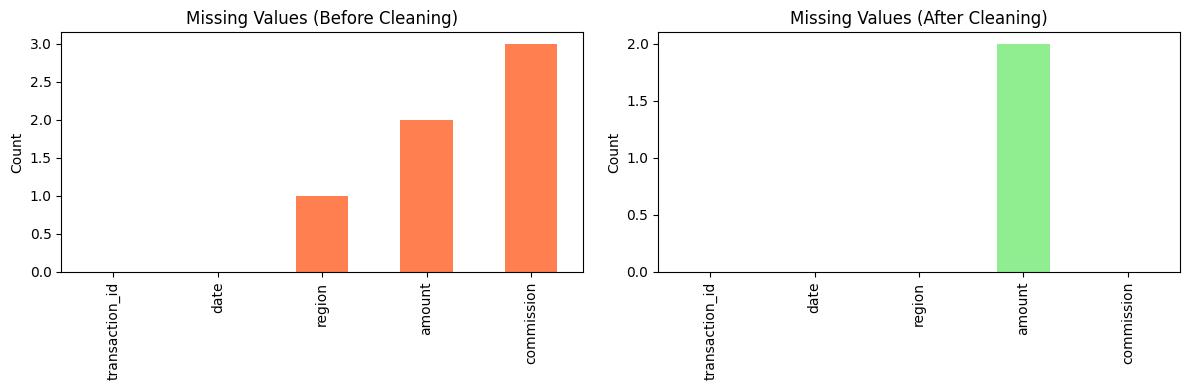

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Raw sales data with multiple quality issues
raw_sales = pd.DataFrame({
    'transaction_id': [101, 102, 102, 103, 104, 105, 105, 106],
    'date': ['2024-01-01', '2024-01-02', '2024-01-02', '2024-01-03',
             '2024-01-04', '2024-01-05', '2024-01-05', '2024-01-06'],
    'region':     ['North', 'South', 'South', 'North', 'East', 'West', 'West', None],
    'amount':     [1000, np.nan, 1500, 2000, np.nan, 3000, 3000, 2500],
    'commission': [100, 150, np.nan, 200, 250, np.nan, 300, np.nan]
})

print("=" * 60)
print("ORIGINAL DATA (Messy)")
print("=" * 60)
print(raw_sales)
print(f"\nMissing values:\n{raw_sales.isna().sum()}")
print(f"Duplicate rows: {raw_sales.duplicated().sum()}")

# Step 1: Remove duplicate transactions
print("\n" + "=" * 60)
print("STEP 1: Remove Duplicate Transactions")
print("=" * 60)
sales = raw_sales.drop_duplicates(subset=['transaction_id'], keep='first')
print(f"Rows after removing duplicates: {len(sales)}")
print(sales)

# Step 2: Fill missing region with 'Unknown'
print("\n" + "=" * 60)
print("STEP 2: Fill Missing Region")
print("=" * 60)
sales['region'] = sales['region'].fillna('Unknown')
print(sales[['transaction_id', 'region']])

# Step 3: Fill missing amounts with regional mean
print("\n" + "=" * 60)
print("STEP 3: Fill Missing Amounts (by Region)")
print("=" * 60)
sales['amount'] = sales.groupby('region')['amount'].transform(
    lambda x: x.fillna(x.mean())
)
print(sales[['transaction_id', 'region', 'amount']])

# Step 4: Fill missing commission with overall median
print("\n" + "=" * 60)
print("STEP 4: Fill Missing Commission")
print("=" * 60)
sales['commission'] = sales['commission'].fillna(sales['commission'].median())
print(sales[['transaction_id', 'commission']])

# Step 5: Verify cleaned data
print("\n" + "=" * 60)
print("FINAL CLEANED DATA")
print("=" * 60)
print(sales)
print(f"\nMissing values remaining: {sales.isna().sum().sum()}")
print(f"Duplicate rows remaining: {sales.duplicated().sum()}")

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw_sales.isna().sum().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Missing Values (Before Cleaning)')
axes[0].set_ylabel('Count')

sales.isna().sum().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Missing Values (After Cleaning)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---

## Quick Reference

| Scenario | Method | Why |
|---|---|---|
| < 5% missing, random | `dropna()` | Safe to remove without bias |
| Logical default exists | `fillna(value)` | E.g., 0 for counts, "Unknown" for categories |
| Time-series data | `ffill()` or `bfill()` | Preserves temporal continuity |
| Numeric sequence | `interpolate()` | Estimates missing values from pattern |
| Group-based pattern | `groupby().transform()` | Fill with group mean/median |
| Features are correlated | `KNNImputer` or `IterativeImputer` | Uses relationships between columns |
| Exact duplicates | `drop_duplicates()` | Remove data entry errors |
| Partial duplicates | `drop_duplicates(subset=[...])` | Keep first/last occurrence |
| Investigate duplicates | `duplicated(keep=False)` | Inspect before removing |

---

## Summary

Handling missing data and duplicates requires a thoughtful, systematic approach:

1. **Detect** missing values using `isna()`, `notna()`, `.info()`, and visual tools
2. **Understand** the pattern and extent of missingness before choosing a strategy
3. **Choose** an appropriate method — removal, constant fill, statistical imputation, forward/backward fill, interpolation, or advanced imputation — based on your data type and the mechanism of missingness
4. **Handle duplicates** alongside missing data as part of a unified cleaning pipeline
5. **Validate** that your approach hasn't introduced bias or distorted distributions
6. **Document** your decisions for reproducibility

The best approach always depends on your specific dataset, the amount of missing data, and your analysis goals. When in doubt, consult domain experts, run a sensitivity analysis across methods, and validate results against the original data patterns.

---

# Exercises

Test your understanding of this chapter's concepts.

### Exercise 1: Detecting Missing Data

Given a DataFrame containing employee records with missing values, use pandas methods to detect and summarize the missing data. Calculate both the count and percentage of missing values for each column.

In [90]:
import pandas as pd
import numpy as np

# Employee records DataFrame
df = pd.DataFrame({
    'employee_id': [101, 102, 103, 104, 105, 106],
    'name': ['Alice', 'Bob', None, 'Diana', 'Eve', 'Frank'],
    'department': ['HR', 'IT', 'IT', None, 'HR', None],
    'salary': [55000, 72000, np.nan, 61000, np.nan, 68000],
    'years_exp': [3, 7, np.nan, 5, 2, np.nan]
})

# TODO: Check which cells are missing (boolean DataFrame)
missing_mask = None

# TODO: Count missing values per column
missing_counts = None

# TODO: Calculate the percentage of missing values per column (round to 2 decimal places)
missing_pct = None

# TODO: Create a summary DataFrame with columns 'missing_count' and 'missing_pct'
#       and filter it to show only columns that have at least one missing value
summary = None

print("Missing value mask:")
print(missing_mask)
print("\nMissing data summary:")
print(summary)

Missing value mask:
None

Missing data summary:
None


### Exercise 2: Removing Missing Data

Work with a sales dataset that contains missing values and practice removing rows and columns based on different threshold conditions. Explore how the 'thresh' and 'subset' parameters of dropna() affect the resulting DataFrame.

In [91]:
import pandas as pd
import numpy as np

# Sales dataset
df = pd.DataFrame({
    'order_id':   [1,      2,      3,      4,      5,      6],
    'customer':   ['Ana',  'Ben',  None,   'Dan',  None,   'Fay'],
    'product':    ['A',    'B',    'C',    None,   'A',    'B'],
    'quantity':   [10,     np.nan, 5,      8,      np.nan, 3],
    'price':      [100.0,  200.0,  np.nan, 150.0,  np.nan, np.nan],
    'discount':   [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

print("Original DataFrame:")
print(df)
print()

# TODO: Drop the 'discount' column because it is entirely empty
#       (drop any column where ALL values are missing)
df_no_empty_cols = None

# TODO: Drop rows where BOTH 'customer' AND 'quantity' are missing
#       (use the subset parameter)
df_key_cols = None

# TODO: Drop rows that have fewer than 3 non-missing values
#       (use the thresh parameter on df_no_empty_cols)
df_thresh = None

print("After dropping fully-empty columns:")
print(df_no_empty_cols)
print("\nAfter dropping rows missing both customer and quantity:")
print(df_key_cols)
print("\nAfter applying thresh=3:")
print(df_thresh)

Original DataFrame:
   order_id customer product  quantity  price  discount
0         1      Ana       A      10.0  100.0       NaN
1         2      Ben       B       NaN  200.0       NaN
2         3     None       C       5.0    NaN       NaN
3         4      Dan    None       8.0  150.0       NaN
4         5     None       A       NaN    NaN       NaN
5         6      Fay       B       3.0    NaN       NaN

After dropping fully-empty columns:
None

After dropping rows missing both customer and quantity:
None

After applying thresh=3:
None


### Exercise 3: Imputation Strategies

A weather dataset has missing temperature, humidity, and wind-speed readings. Fill in the missing values using different imputation strategies: mean imputation for temperature, forward-fill for humidity, and median imputation grouped by city for wind speed.

In [92]:
import pandas as pd
import numpy as np

# Weather readings dataset
df = pd.DataFrame({
    'city':        ['NYC', 'NYC', 'NYC', 'LA',  'LA',  'LA'],
    'day':         [1,     2,     3,     1,     2,     3],
    'temperature': [22.0,  np.nan, 24.0, 30.0,  31.0,  np.nan],
    'humidity':    [60.0,  np.nan, np.nan, 40.0, np.nan, 38.0],
    'wind_speed':  [np.nan, 15.0,  np.nan, 10.0, np.nan, 12.0]
})

print("Original DataFrame:")
print(df)
print()

# TODO: Fill missing 'temperature' values with the overall mean temperature
df['temperature'] = None

# TODO: Fill missing 'humidity' values using forward-fill
df['humidity'] = None

# TODO: Fill missing 'wind_speed' values with the median wind_speed
#       within each city group (use groupby + transform)
df['wind_speed'] = None

print("After imputation:")
print(df)
print("\nRemaining missing values:")
print(df.isnull().sum())

Original DataFrame:
  city  day  temperature  humidity  wind_speed
0  NYC    1         22.0      60.0         NaN
1  NYC    2          NaN       NaN        15.0
2  NYC    3         24.0       NaN         NaN
3   LA    1         30.0      40.0        10.0
4   LA    2         31.0       NaN         NaN
5   LA    3          NaN      38.0        12.0

After imputation:
  city  day temperature humidity wind_speed
0  NYC    1        None     None       None
1  NYC    2        None     None       None
2  NYC    3        None     None       None
3   LA    1        None     None       None
4   LA    2        None     None       None
5   LA    3        None     None       None

Remaining missing values:
city           0
day            0
temperature    6
humidity       6
wind_speed     6
dtype: int64


### Exercise 4: Identifying and Removing Duplicates

A customer transactions dataset contains several types of duplicate records. Identify fully duplicated rows, find rows with duplicate transaction IDs, and remove duplicates while keeping the most recent entry based on a timestamp column.

In [94]:
import pandas as pd
import numpy as np

# Customer transactions dataset
df = pd.DataFrame({
    'txn_id':    [1001, 1002, 1003, 1001, 1004, 1002, 1005],
    'customer':  ['Alice', 'Bob', 'Carol', 'Alice', 'Dave', 'Bob', 'Eve'],
    'amount':    [250.0, 89.5, 430.0, 250.0, 175.0, 89.5, 310.0],
    'timestamp': pd.to_datetime([
                    '2024-01-01 09:00',
                    '2024-01-01 10:00',
                    '2024-01-02 11:00',
                    '2024-01-01 09:00',
                    '2024-01-03 14:00',
                    '2024-01-04 10:30',
                    '2024-01-04 16:00'
                 ])
})

print("Original DataFrame:")
print(df)
print()

# TODO: Identify and print all fully duplicated rows (all columns match)
full_duplicates = None
print("Fully duplicated rows:")
print(full_duplicates)
print()

# TODO: Identify rows with a duplicated 'txn_id' (any occurrence after the first)
txn_duplicates = None
print("Rows with duplicate txn_id:")
print(txn_duplicates)
print()

# TODO: Remove duplicate 'txn_id' rows, keeping the row with the LATEST timestamp.
#       Hint: sort by timestamp first, then drop duplicates keeping the last.
df_clean = None

print("Cleaned DataFrame (latest transaction per txn_id):")
# print(df_clean.sort_values('txn_id').reset_index(drop=True))

Original DataFrame:
   txn_id customer  amount           timestamp
0    1001    Alice   250.0 2024-01-01 09:00:00
1    1002      Bob    89.5 2024-01-01 10:00:00
2    1003    Carol   430.0 2024-01-02 11:00:00
3    1001    Alice   250.0 2024-01-01 09:00:00
4    1004     Dave   175.0 2024-01-03 14:00:00
5    1002      Bob    89.5 2024-01-04 10:30:00
6    1005      Eve   310.0 2024-01-04 16:00:00

Fully duplicated rows:
None

Rows with duplicate txn_id:
None

Cleaned DataFrame (latest transaction per txn_id):


---

# Solutions

*Scroll down only after you've attempted the exercises above.*

<br><br><br><br><br><br><br><br><br><br>

### Solution 1: Detecting Missing Data

In [95]:
import pandas as pd
import numpy as np

# Employee records DataFrame
df = pd.DataFrame({
    'employee_id': [101, 102, 103, 104, 105, 106],
    'name': ['Alice', 'Bob', None, 'Diana', 'Eve', 'Frank'],
    'department': ['HR', 'IT', 'IT', None, 'HR', None],
    'salary': [55000, 72000, np.nan, 61000, np.nan, 68000],
    'years_exp': [3, 7, np.nan, 5, 2, np.nan]
})

# Check which cells are missing (boolean DataFrame)
missing_mask = df.isnull()

# Count missing values per column
missing_counts = df.isnull().sum()

# Calculate the percentage of missing values per column (round to 2 decimal places)
missing_pct = round(df.isnull().mean() * 100, 2)

# Create a summary DataFrame with columns 'missing_count' and 'missing_pct'
# and filter it to show only columns that have at least one missing value
summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})
summary = summary[summary['missing_count'] > 0]

print("Missing value mask:")
print(missing_mask)
print("\nMissing data summary:")
print(summary)

Missing value mask:
   employee_id   name  department  salary  years_exp
0        False  False       False   False      False
1        False  False       False   False      False
2        False   True       False    True       True
3        False  False        True   False      False
4        False  False       False    True      False
5        False  False        True   False       True

Missing data summary:
            missing_count  missing_pct
name                    1        16.67
department              2        33.33
salary                  2        33.33
years_exp               2        33.33


### Solution 2: Removing Missing Data

In [96]:
import pandas as pd
import numpy as np

# Sales dataset
df = pd.DataFrame({
    'order_id':   [1,      2,      3,      4,      5,      6],
    'customer':   ['Ana',  'Ben',  None,   'Dan',  None,   'Fay'],
    'product':    ['A',    'B',    'C',    None,   'A',    'B'],
    'quantity':   [10,     np.nan, 5,      8,      np.nan, 3],
    'price':      [100.0,  200.0,  np.nan, 150.0,  np.nan, np.nan],
    'discount':   [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

print("Original DataFrame:")
print(df)
print()

# Drop any column where ALL values are missing
df_no_empty_cols = df.dropna(axis=1, how='all')

# Drop rows where BOTH 'customer' AND 'quantity' are missing
df_key_cols = df.dropna(subset=['customer', 'quantity'], how='all')

# Drop rows that have fewer than 3 non-missing values (using df_no_empty_cols)
df_thresh = df_no_empty_cols.dropna(thresh=3)

print("After dropping fully-empty columns:")
print(df_no_empty_cols)
print("\nAfter dropping rows missing both customer and quantity:")
print(df_key_cols)
print("\nAfter applying thresh=3:")
print(df_thresh)

Original DataFrame:
   order_id customer product  quantity  price  discount
0         1      Ana       A      10.0  100.0       NaN
1         2      Ben       B       NaN  200.0       NaN
2         3     None       C       5.0    NaN       NaN
3         4      Dan    None       8.0  150.0       NaN
4         5     None       A       NaN    NaN       NaN
5         6      Fay       B       3.0    NaN       NaN

After dropping fully-empty columns:
   order_id customer product  quantity  price
0         1      Ana       A      10.0  100.0
1         2      Ben       B       NaN  200.0
2         3     None       C       5.0    NaN
3         4      Dan    None       8.0  150.0
4         5     None       A       NaN    NaN
5         6      Fay       B       3.0    NaN

After dropping rows missing both customer and quantity:
   order_id customer product  quantity  price  discount
0         1      Ana       A      10.0  100.0       NaN
1         2      Ben       B       NaN  200.0       NaN
2   

### Solution 3: Imputation Strategies

In [97]:
import pandas as pd
import numpy as np

# Weather readings dataset
df = pd.DataFrame({
    'city':        ['NYC', 'NYC', 'NYC', 'LA',  'LA',  'LA'],
    'day':         [1,     2,     3,     1,     2,     3],
    'temperature': [22.0,  np.nan, 24.0, 30.0,  31.0,  np.nan],
    'humidity':    [60.0,  np.nan, np.nan, 40.0, np.nan, 38.0],
    'wind_speed':  [np.nan, 15.0,  np.nan, 10.0, np.nan, 12.0]
})

print("Original DataFrame:")
print(df)
print()

# Fill missing 'temperature' values with the overall mean temperature
df['temperature'] = df['temperature'].fillna(df['temperature'].mean())

# Fill missing 'humidity' values using forward-fill
df['humidity'] = df['humidity'].ffill()

# Fill missing 'wind_speed' values with the median wind_speed within each city group
df['wind_speed'] = df.groupby('city')['wind_speed'].transform(
    lambda x: x.fillna(x.median())
)

print("After imputation:")
print(df)
print("\nRemaining missing values:")
print(df.isnull().sum())

Original DataFrame:
  city  day  temperature  humidity  wind_speed
0  NYC    1         22.0      60.0         NaN
1  NYC    2          NaN       NaN        15.0
2  NYC    3         24.0       NaN         NaN
3   LA    1         30.0      40.0        10.0
4   LA    2         31.0       NaN         NaN
5   LA    3          NaN      38.0        12.0

After imputation:
  city  day  temperature  humidity  wind_speed
0  NYC    1        22.00      60.0        15.0
1  NYC    2        26.75      60.0        15.0
2  NYC    3        24.00      60.0        15.0
3   LA    1        30.00      40.0        10.0
4   LA    2        31.00      40.0        11.0
5   LA    3        26.75      38.0        12.0

Remaining missing values:
city           0
day            0
temperature    0
humidity       0
wind_speed     0
dtype: int64


### Solution 4: Identifying and Removing Duplicates

In [98]:
import pandas as pd
import numpy as np

# Customer transactions dataset
df = pd.DataFrame({
    'txn_id':    [1001, 1002, 1003, 1001, 1004, 1002, 1005],
    'customer':  ['Alice', 'Bob', 'Carol', 'Alice', 'Dave', 'Bob', 'Eve'],
    'amount':    [250.0, 89.5, 430.0, 250.0, 175.0, 89.5, 310.0],
    'timestamp': pd.to_datetime([
                    '2024-01-01 09:00',
                    '2024-01-01 10:00',
                    '2024-01-02 11:00',
                    '2024-01-01 09:00',
                    '2024-01-03 14:00',
                    '2024-01-04 10:30',
                    '2024-01-04 16:00'
                 ])
})

print("Original DataFrame:")
print(df)
print()

# Identify and print all fully duplicated rows (all columns match)
full_duplicates = df[df.duplicated(keep=False)]
print("Fully duplicated rows:")
print(full_duplicates)
print()

# Identify rows with a duplicated 'txn_id' (any occurrence after the first)
txn_duplicates = df[df.duplicated(subset=['txn_id'], keep='first')]
print("Rows with duplicate txn_id:")
print(txn_duplicates)
print()

# Remove duplicate 'txn_id' rows, keeping the row with the LATEST timestamp.
# Sort by timestamp ascending, then drop duplicates keeping the last occurrence.
df_clean = (
    df.sort_values('timestamp')
      .drop_duplicates(subset=['txn_id'], keep='last')
)

print("Cleaned DataFrame (latest transaction per txn_id):")
print(df_clean.sort_values('txn_id').reset_index(drop=True))

Original DataFrame:
   txn_id customer  amount           timestamp
0    1001    Alice   250.0 2024-01-01 09:00:00
1    1002      Bob    89.5 2024-01-01 10:00:00
2    1003    Carol   430.0 2024-01-02 11:00:00
3    1001    Alice   250.0 2024-01-01 09:00:00
4    1004     Dave   175.0 2024-01-03 14:00:00
5    1002      Bob    89.5 2024-01-04 10:30:00
6    1005      Eve   310.0 2024-01-04 16:00:00

Fully duplicated rows:
   txn_id customer  amount           timestamp
0    1001    Alice   250.0 2024-01-01 09:00:00
3    1001    Alice   250.0 2024-01-01 09:00:00

Rows with duplicate txn_id:
   txn_id customer  amount           timestamp
3    1001    Alice   250.0 2024-01-01 09:00:00
5    1002      Bob    89.5 2024-01-04 10:30:00

Cleaned DataFrame (latest transaction per txn_id):
   txn_id customer  amount           timestamp
0    1001    Alice   250.0 2024-01-01 09:00:00
1    1002      Bob    89.5 2024-01-04 10:30:00
2    1003    Carol   430.0 2024-01-02 11:00:00
3    1004     Dave   175.0 20